<a href="https://colab.research.google.com/github/aishwarya602/Hybrid_Server_Load_Balancer/blob/main/Hybrid_Load_Balancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import threading
import time
import random
from queue import Queue

# Backend Server class
class Server:
    def __init__(self, name):
        self.name = name
        self.request_count = 0

    def handle_request(self, request):
        self.request_count += 1
        print(f"[{self.name}] Handling request: {request}")
        time.sleep(random.uniform(0.5, 2))  # Simulate processing time
        print(f"[{self.name}] Completed request: {request}")

# Load Balancer class
class LoadBalancer:
    def __init__(self, servers):
        self.servers = servers
        self.lock = threading.Lock()
        self.current_server = 0

    def get_server(self):
        with self.lock:
            server = self.servers[self.current_server]
            self.current_server = (self.current_server + 1) % len(self.servers)
        return server

    def handle_request(self, request):
        server = self.get_server()
        server.handle_request(request)

# Client Simulator
def client_simulator(load_balancer, num_requests):
    for i in range(1, num_requests + 1):
        threading.Thread(target=load_balancer.handle_request, args=(f"Request-{i}",)).start()
        time.sleep(random.uniform(0.1, 0.5))  # Simulate time between requests

# Main function
def main():
    # Create backend servers
    servers = [Server(f"Server-{i+1}") for i in range(3)]

    # Create load balancer
    load_balancer = LoadBalancer(servers)

    # Simulate clients sending requests
    num_requests = 20
    client_simulator(load_balancer, num_requests)

    # Wait for all threads to complete
    time.sleep(5)

    # Display server stats
    print("\nServer Statistics:")
    for server in servers:
        print(f"{server.name}: {server.request_count} requests handled")

if __name__ == "__main__":
    main()


[Server-1] Handling request: Request-1
[Server-2] Handling request: Request-2
[Server-3] Handling request: Request-3
[Server-1] Handling request: Request-4
[Server-1] Completed request: Request-1
[Server-2] Completed request: Request-2
[Server-2] Handling request: Request-5
[Server-3] Handling request: Request-6
[Server-3] Completed request: Request-3
[Server-1] Completed request: Request-4
[Server-1] Handling request: Request-7
[Server-2] Completed request: Request-5
[Server-2] Handling request: Request-8
[Server-3] Handling request: Request-9
[Server-1] Handling request: Request-10
[Server-1] Completed request: Request-7
[Server-2] Completed request: Request-8
[Server-3] Completed request: Request-6
[Server-3] Completed request: Request-9
[Server-2] Handling request: Request-11
[Server-1] Completed request: Request-10
[Server-3] Handling request: Request-12
[Server-2] Completed request: Request-11
[Server-1] Handling request: Request-13
[Server-2] Handling request: Request-14
[Server

In [ ]:
import threading
import time
import random
from queue import Queue

# Backend Server class
class Server:
    def __init__(self, name):
        self.name = name
        self.request_count = 0

    def handle_request(self, request):
        self.request_count += 1
        print(f"[{self.name}] Handling request: {request}")
        time.sleep(random.uniform(0.5, 2))  # Simulate processing time
        print(f"[{self.name}] Completed request: {request}")

# Load Balancer class
class LoadBalancer:
    def __init__(self, servers):
        self.servers = servers
        self.lock = threading.Lock()
        self.current_server = 0

    def get_server(self):
        with self.lock:
            server = self.servers[self.current_server]
            self.current_server = (self.current_server + 1) % len(self.servers)
        return server

    def process_request(self, request):
        server = self.get_server()
        server.handle_request(request)

# Worker Thread for Non-Realtime Processing
def request_processor(load_balancer, request_queue):
    while True:
        request = request_queue.get()  # Wait for a request
        if request is None:  # Stop signal
            break
        load_balancer.process_request(request)
        request_queue.task_done()

# Client Simulator
def client_simulator(request_queue, num_requests):
    for i in range(1, num_requests + 1):
        request = f"Request-{i}"
        print(f"Enqueuing {request}")
        request_queue.put(request)
        time.sleep(random.uniform(0.1, 0.5))  # Simulate time between requests

# Main function
def main():
    # Create backend servers
    servers = [Server(f"Server-{i+1}") for i in range(3)]

    # Create load balancer
    load_balancer = LoadBalancer(servers)

    # Create a request queue
    request_queue = Queue()

    # Start the worker thread
    worker_thread = threading.Thread(target=request_processor, args=(load_balancer, request_queue))
    worker_thread.start()

    # Simulate clients sending requests
    num_requests = 20
    client_simulator(request_queue, num_requests)

    # Wait for all requests to be processed
    request_queue.join()

    # Stop the worker thread
    request_queue.put(None)  # Send stop signal
    worker_thread.join()

    # Display server stats
    print("\nServer Statistics:")
    for server in servers:
        print(f"{server.name}: {server.request_count} requests handled")

if __name__ == "__main__":
    main()


Enqueuing Request-1
[Server-1] Handling request: Request-1
Enqueuing Request-2
Enqueuing Request-3
Enqueuing Request-4
[Server-1] Completed request: Request-1
[Server-2] Handling request: Request-2
Enqueuing Request-5
Enqueuing Request-6
Enqueuing Request-7
Enqueuing Request-8
[Server-2] Completed request: Request-2
[Server-3] Handling request: Request-3
Enqueuing Request-9
Enqueuing Request-10
Enqueuing Request-11
Enqueuing Request-12
Enqueuing Request-13
[Server-3] Completed request: Request-3
[Server-1] Handling request: Request-4
Enqueuing Request-14
Enqueuing Request-15
Enqueuing Request-16
[Server-1] Completed request: Request-4
[Server-2] Handling request: Request-5
Enqueuing Request-17
Enqueuing Request-18
[Server-2] Completed request: Request-5
[Server-3] Handling request: Request-6
Enqueuing Request-19
Enqueuing Request-20
[Server-3] Completed request: Request-6
[Server-1] Handling request: Request-7
[Server-1] Completed request: Request-7
[Server-2] Handling request: Request

In [ ]:
import threading
import time
from queue import Queue

# Simulating server instances
def server_handler(server_id, request):
    print(f"Server {server_id} is processing request {request}")
    time.sleep(1)  # Simulate some processing time
    print(f"Server {server_id} completed request {request}")

# Load balancer class using round-robin
def round_robin_load_balancer(servers, request_queue):
    server_count = len(servers)
    index = 0

    while not request_queue.empty():
        request = request_queue.get()
        server_id = servers[index]

        # Assign request to the selected server
        threading.Thread(target=server_handler, args=(server_id, request)).start()

        # Move to the next server in round-robin fashion
        index = (index + 1) % server_count

if __name__ == "__main__":
    # List of servers (could be IPs, IDs, or other identifiers)
    servers = ["Server-1", "Server-2", "Server-3"]

    # Queue of incoming requests
    request_queue = Queue()
    for i in range(1, 11):  # Simulate 10 requests
        request_queue.put(f"Request-{i}")

    # Start the load balancer
    round_robin_load_balancer(servers, request_queue)

    # Keep the main thread alive to let all threads complete
    time.sleep(15)


Server Server-1 is processing request Request-1
Server Server-2 is processing request Request-2
Server Server-3 is processing request Request-3
Server Server-1 is processing request Request-4
Server Server-2 is processing request Request-5
Server Server-3 is processing request Request-6
Server Server-1 is processing request Request-7
Server Server-2 is processing request Request-8
Server Server-3 is processing request Request-9
Server Server-1 is processing request Request-10
Server Server-1 completed request Request-1
Server Server-2 completed request Request-2
Server Server-3 completed request Request-3
Server Server-1 completed request Request-4
Server Server-2 completed request Request-5
Server Server-3 completed request Request-6
Server Server-1 completed request Request-7
Server Server-2 completed request Request-8
Server Server-3 completed request Request-9
Server Server-1 completed request Request-10


In [ ]:
from celery import Celery
import time

# Initialize Celery app
app = Celery('load_balancer', broker='redis://localhost:6379/0')

# Simulating server instances
@app.task
def server_handler(server_id, request):
    print(f"Server {server_id} is processing request {request}")
    time.sleep(1)  # Simulate some processing time
    print(f"Server {server_id} completed request {request}")

# Load balancer class using round-robin
def round_robin_load_balancer(servers, requests):
    server_count = len(servers)
    index = 0

    for request in requests:
        server_id = servers[index]

        # Assign request to the selected server using Celery
        server_handler.delay(server_id, request)

        # Move to the next server in round-robin fashion
        index = (index + 1) % server_count

if __name__ == "__main__":
    # List of servers (could be IPs, IDs, or other identifiers)
    servers = ["Server-1", "Server-2", "Server-3"]

    # List of incoming requests
    requests = [f"Request-{i}" for i in range(1, 11)]  # Simulate 10 requests

    # Start the load balancer
    round_robin_load_balancer(servers, requests)

    print("All requests have been dispatched to servers.")


ModuleNotFoundError: No module named 'celery'

In [ ]:
import itertools
import threading
import time

# Simulating server instances
def server_handler(server_id, request):
    print(f"Server {server_id} is processing request {request}")
    time.sleep(1)  # Simulate some processing time
    print(f"Server {server_id} completed request {request}")

# Load balancer class using round-robin
def round_robin_load_balancer(servers, requests):
    # Cycle through servers infinitely
    server_cycle = itertools.cycle(servers)

    for request in requests:
        server_id = next(server_cycle)

        # Assign request to the selected server using threading
        threading.Thread(target=server_handler, args=(server_id, request)).start()

if __name__ == "__main__":
    # List of servers (could be IPs, IDs, or other identifiers)
    servers = ["Server-1", "Server-2", "Server-3"]

    # List of incoming requests
    requests = [f"Request-{i}" for i in range(1, 11)]  # Simulate 10 requests

    # Start the load balancer
    round_robin_load_balancer(servers, requests)

    # Keep the main thread alive to let all threads complete
    time.sleep(15)


Server Server-1 is processing request Request-1
Server Server-2 is processing request Request-2
Server Server-3 is processing request Request-3
Server Server-1 is processing request Request-4
Server Server-2 is processing request Request-5
Server Server-3 is processing request Request-6
Server Server-1 is processing request Request-7
Server Server-2 is processing request Request-8
Server Server-3 is processing request Request-9
Server Server-1 is processing request Request-10
Server Server-1 completed request Request-1
Server Server-2 completed request Request-2
Server Server-3 completed request Request-3
Server Server-1 completed request Request-4
Server Server-3 completed request Request-6
Server Server-2 completed request Request-5
Server Server-1 completed request Request-7
Server Server-2 completed request Request-8
Server Server-3 completed request Request-9
Server Server-1 completed request Request-10


In [ ]:
class RoundRobinLoadBalancer:
    def __init__(self, servers):
        self.servers = servers
        self.index = 0  # Keeps track of the last assigned server

    def get_server(self):
        """Returns the next server using round-robin scheduling."""
        if not self.servers:
            raise ValueError("No servers available")
        server = self.servers[self.index]
        self.index = (self.index + 1) % len(self.servers)
        return server

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3", "Server4"]
    load_balancer = RoundRobinLoadBalancer(servers)

    # Simulate distributing requests
    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")


Request 1 is handled by Server1
Request 2 is handled by Server2
Request 3 is handled by Server3
Request 4 is handled by Server4
Request 5 is handled by Server1
Request 6 is handled by Server2
Request 7 is handled by Server3
Request 8 is handled by Server4
Request 9 is handled by Server1
Request 10 is handled by Server2


In [ ]:
class WeightedRoundRobinLoadBalancer:
    def __init__(self, servers):
        self.servers = []
        for server, weight in servers.items():
            self.servers.extend([server] * weight)
        self.index = 0  # Keeps track of the last assigned server

    def get_server(self):
        """Returns the next server using weighted round-robin scheduling."""
        if not self.servers:
            raise ValueError("No servers available")
        server = self.servers[self.index]
        self.index = (self.index + 1) % len(self.servers)
        return server

# Example usage:
if __name__ == "__main__":
    servers = {"Server1": 3, "Server2": 1, "Server3": 2}  # Server weights
    load_balancer = WeightedRoundRobinLoadBalancer(servers)

    # Simulate distributing requests
    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server2
Request 5 is handled by Server3
Request 6 is handled by Server3
Request 7 is handled by Server1
Request 8 is handled by Server1
Request 9 is handled by Server1
Request 10 is handled by Server2


In [ ]:
class LeastConnectionsLoadBalancer:
    def __init__(self, servers):
        self.servers = {server: 0 for server in servers}  # Store servers with their active connections

    def get_server(self):
        """Returns the server with the least number of active connections."""
        if not self.servers:
            raise ValueError("No servers available")
        server = min(self.servers, key=self.servers.get)  # Choose the server with the least connections
        self.servers[server] += 1  # Increment the connection count
        return server

    def release_connection(self, server):
        """Decreases the connection count for a given server."""
        if server in self.servers and self.servers[server] > 0:
            self.servers[server] -= 1

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3"]  # List of servers
    load_balancer = LeastConnectionsLoadBalancer(servers)

    # Simulate distributing requests
    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate request completion and releasing connection
        load_balancer.release_connection(assigned_server)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server1
Request 5 is handled by Server1
Request 6 is handled by Server1
Request 7 is handled by Server1
Request 8 is handled by Server1
Request 9 is handled by Server1
Request 10 is handled by Server1


In [ ]:
class LoadBasedLoadBalancer:
    def __init__(self, servers):
        self.servers = {server: {'connections': 0, 'load': 0} for server in servers}  # Store servers with connections and load

    def get_server(self):
        """Returns the server with the least load."""
        if not self.servers:
            raise ValueError("No servers available")
        server = min(self.servers, key=lambda s: self.servers[s]['load'])  # Choose the server with the least load
        self.servers[server]['connections'] += 1  # Increment connection count
        self.servers[server]['load'] += self.calculate_load(server)  # Update load factor
        return server

    def release_connection(self, server):
        """Decreases the connection count and adjusts load for a given server."""
        if server in self.servers and self.servers[server]['connections'] > 0:
            self.servers[server]['connections'] -= 1
            self.servers[server]['load'] -= self.calculate_load(server)

    def calculate_load(self, server):
        """Custom logic to calculate load, can be adjusted as per requirements."""
        return 1 + (self.servers[server]['connections'] * 0.1)  # Example load calculation

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3"]  # List of servers
    load_balancer = LoadBasedLoadBalancer(servers)

    # Simulate distributing requests
    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate request completion and releasing connection
        load_balancer.release_connection(assigned_server)


Request 1 is handled by Server1
Request 2 is handled by Server2
Request 3 is handled by Server3
Request 4 is handled by Server1
Request 5 is handled by Server2
Request 6 is handled by Server3
Request 7 is handled by Server1
Request 8 is handled by Server2
Request 9 is handled by Server3
Request 10 is handled by Server1


In [ ]:
import numpy as np
import random

class RLLoadBalancer:
    def __init__(self, servers, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.servers = servers
        self.q_table = {server: 0 for server in servers}  # Initialize Q-values for servers
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate

    def get_server(self):
        """Selects a server using an epsilon-greedy policy."""
        if random.uniform(0, 1) < self.epsilon:
            server = random.choice(self.servers)  # Explore
        else:
            server = min(self.q_table, key=self.q_table.get)  # Exploit (choose the best server)
        return server

    def update_q_values(self, server, reward):
        """Updates the Q-table based on feedback (reward)."""
        self.q_table[server] = self.q_table[server] + self.alpha * (
            reward + self.gamma * min(self.q_table.values()) - self.q_table[server]
        )

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3"]
    load_balancer = RLLoadBalancer(servers)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward based on response time or load efficiency)
        reward = random.uniform(-1, 1)  # Example reward mechanism
        load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server2
Request 3 is handled by Server3
Request 4 is handled by Server2
Request 5 is handled by Server2
Request 6 is handled by Server1
Request 7 is handled by Server3
Request 8 is handled by Server3
Request 9 is handled by Server3
Request 10 is handled by Server3


In [ ]:
import numpy as np
import random

class HybridLoadBalancer:
    def __init__(self, servers, weights=None, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.servers = servers
        self.weights = weights if weights else {server: 1 for server in servers}  # Weighted RR
        self.q_table = {server: 0 for server in servers}  # Initialize Q-values for RL
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.connection_counts = {server: 0 for server in servers}  # Least Connections
        self.index = 0  # Round Robin index

    def get_server(self):
        """Selects a server using a hybrid approach."""
        # Weighted Round Robin Logic
        sorted_servers = sorted(self.weights, key=self.weights.get, reverse=True)
        rr_server = sorted_servers[self.index % len(sorted_servers)]
        self.index += 1

        # Least Connections Logic
        lc_server = min(self.connection_counts, key=self.connection_counts.get)

        # RL Logic (Epsilon-Greedy)
        if random.uniform(0, 1) < self.epsilon:
            rl_server = random.choice(self.servers)  # Explore
        else:
            rl_server = min(self.q_table, key=self.q_table.get)  # Exploit

        # Choose the best server among the three strategies
        selected_server = min([rr_server, lc_server, rl_server], key=lambda s: self.q_table[s])
        self.connection_counts[selected_server] += 1  # Simulate connection increment
        return selected_server

    def update_q_values(self, server, reward):
        """Updates the Q-table based on feedback (reward)."""
        self.q_table[server] = self.q_table[server] + self.alpha * (
            reward + self.gamma * min(self.q_table.values()) - self.q_table[server]
        )
        self.connection_counts[server] = max(0, self.connection_counts[server] - 1)  # Release connection

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3"]
    weights = {"Server1": 3, "Server2": 1, "Server3": 2}  # Weights for WRR
    load_balancer = HybridLoadBalancer(servers, weights)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward based on response time or load efficiency)
        reward = random.uniform(-1, 1)  # Example reward mechanism
        load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server1
Request 5 is handled by Server1
Request 6 is handled by Server1
Request 7 is handled by Server1
Request 8 is handled by Server1
Request 9 is handled by Server2
Request 10 is handled by Server2


Code without numpy library


In [ ]:
import random

class HybridLoadBalancer:
    def __init__(self, servers, weights=None, alpha=0.1, gamma=0.9, epsilon=0.1):
        self.servers = servers
        self.weights = weights if weights else {server: 1 for server in servers}  # Weighted RR
        self.q_table = {server: 0 for server in servers}  # Initialize Q-values for RL
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.connection_counts = {server: 0 for server in servers}  # Least Connections
        self.index = 0  # Round Robin index

    def get_server(self):
        """Selects a server using a hybrid approach."""
        # Weighted Round Robin Logic
        sorted_servers = sorted(self.weights, key=self.weights.get, reverse=True)
        rr_server = sorted_servers[self.index % len(sorted_servers)]
        self.index += 1

        # Least Connections Logic
        lc_server = min(self.connection_counts, key=self.connection_counts.get)

        # RL Logic (Epsilon-Greedy)
        if random.uniform(0, 1) < self.epsilon:
            rl_server = random.choice(self.servers)  # Explore
        else:
            rl_server = min(self.q_table, key=self.q_table.get)  # Exploit

        # Choose the best server among the three strategies
        selected_server = min([rr_server, lc_server, rl_server], key=lambda s: self.q_table[s])
        self.connection_counts[selected_server] += 1  # Simulate connection increment
        return selected_server

    def update_q_values(self, server, reward):
        """Updates the Q-table based on feedback (reward)."""
        self.q_table[server] = self.q_table[server] + self.alpha * (
            reward + self.gamma * min(self.q_table.values()) - self.q_table[server]
        )
        self.connection_counts[server] = max(0, self.connection_counts[server] - 1)  # Release connection

# Example usage:
if __name__ == "__main__":
    servers = ["Server1", "Server2", "Server3"]
    weights = {"Server1": 3, "Server2": 1, "Server3": 2}  # Weights for WRR
    load_balancer = HybridLoadBalancer(servers, weights)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward based on response time or load efficiency)
        reward = random.uniform(-1, 1)  # Example reward mechanism
        load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server1
Request 5 is handled by Server1
Request 6 is handled by Server1
Request 7 is handled by Server1
Request 8 is handled by Server1
Request 9 is handled by Server1
Request 10 is handled by Server1


Code with SQL for database

In [ ]:
import random
import sqlite3

class HybridLoadBalancer:
    def __init__(self, db_path="load_balancer.db", alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.index = 0  # Round Robin index

        # Connect to the database
        self.conn = sqlite3.connect(db_path)
        self.cursor = self.conn.cursor()

        # Create tables if they don't exist
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS servers (
                name TEXT PRIMARY KEY,
                weight INTEGER,
                q_value REAL DEFAULT 0,
                connections INTEGER DEFAULT 0
            )
        """)

        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS request_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                server TEXT,
                reward REAL,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
            )
        """)
        self.conn.commit()

    def add_server(self, name, weight):
        """Add a new server to the database."""
        self.cursor.execute("INSERT OR IGNORE INTO servers (name, weight) VALUES (?, ?)", (name, weight))
        self.conn.commit()

    def get_servers(self):
        """Retrieve all servers from the database."""
        self.cursor.execute("SELECT name FROM servers")
        return [row[0] for row in self.cursor.fetchall()]

    def get_server(self):
        """Selects a server using a hybrid approach."""
        self.cursor.execute("SELECT name, weight, q_value, connections FROM servers")
        servers = self.cursor.fetchall()

        if not servers:
            return None

        # Weighted Round Robin (WRR)
        sorted_servers = sorted(servers, key=lambda s: s[1], reverse=True)
        rr_server = sorted_servers[self.index % len(sorted_servers)][0]
        self.index += 1

        # Least Connections (LC)
        lc_server = min(servers, key=lambda s: s[3])[0]

        # Reinforcement Learning (RL) - Epsilon-Greedy
        if random.uniform(0, 1) < self.epsilon:
            rl_server = random.choice(servers)[0]  # Explore
        else:
            rl_server = min(servers, key=lambda s: s[2])[0]  # Exploit

        # Choose the best server
        selected_server = min([rr_server, lc_server, rl_server], key=lambda s: self.get_q_value(s))

        # Update the connections count in the database
        self.cursor.execute("UPDATE servers SET connections = connections + 1 WHERE name = ?", (selected_server,))
        self.conn.commit()

        return selected_server

    def get_q_value(self, server_name):
        """Fetch the Q-value for a given server."""
        self.cursor.execute("SELECT q_value FROM servers WHERE name = ?", (server_name,))
        result = self.cursor.fetchone()
        return result[0] if result else float('inf')

    def update_q_values(self, server, reward):
        """Update the Q-table values in the database."""
        self.cursor.execute("SELECT MIN(q_value) FROM servers")
        min_q_value = self.cursor.fetchone()[0] or 0

        self.cursor.execute("SELECT q_value FROM servers WHERE name = ?", (server,))
        current_q = self.cursor.fetchone()[0] or 0

        new_q = current_q + self.alpha * (reward + self.gamma * min_q_value - current_q)

        self.cursor.execute("UPDATE servers SET q_value = ? WHERE name = ?", (new_q, server))
        self.cursor.execute("UPDATE servers SET connections = MAX(0, connections - 1) WHERE name = ?", (server,))
        self.cursor.execute("INSERT INTO request_logs (server, reward) VALUES (?, ?)", (server, reward))
        self.conn.commit()

if __name__ == "__main__":
    load_balancer = HybridLoadBalancer()

    # Add servers dynamically
    load_balancer.add_server("Server1", 3)
    load_balancer.add_server("Server2", 1)
    load_balancer.add_server("Server3", 2)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward)
        reward = random.uniform(-1, 1)
        load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server2
Request 4 is handled by Server3
Request 5 is handled by Server2
Request 6 is handled by Server2
Request 7 is handled by Server2
Request 8 is handled by Server2
Request 9 is handled by Server2
Request 10 is handled by Server2


In [ ]:
import random
import sqlite3

class HybridLoadBalancer:
    def __init__(self, db_path="load_balancer.db", alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate

        # Connect to the database
        self.conn = sqlite3.connect(db_path)
        self.cursor = self.conn.cursor()

        # Create tables if they don't exist
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS servers (
                name TEXT PRIMARY KEY,
                weight INTEGER,
                q_value REAL DEFAULT 0,
                connections INTEGER DEFAULT 0
            )
        """)

        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS request_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                server TEXT,
                reward REAL,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
            )
        """)
        self.conn.commit()

    def add_server(self, name, weight):
        """Add a new server to the database."""
        self.cursor.execute("INSERT OR IGNORE INTO servers (name, weight) VALUES (?, ?)", (name, weight))
        self.conn.commit()

    def get_server(self):
        """Selects a server using a hybrid SQL-based approach."""
        # Explore with probability epsilon
        if random.uniform(0, 1) < self.epsilon:
            self.cursor.execute("SELECT name FROM servers ORDER BY RANDOM() LIMIT 1")
        else:
            # Exploit - use SQL to find the best server
            self.cursor.execute("""
                SELECT name FROM servers
                ORDER BY q_value ASC, connections ASC, weight DESC
                LIMIT 1
            """)

        result = self.cursor.fetchone()
        if not result:
            return None

        selected_server = result[0]

        # Update connections count
        self.cursor.execute("UPDATE servers SET connections = connections + 1 WHERE name = ?", (selected_server,))
        self.conn.commit()

        return selected_server

    def update_q_values(self, server, reward):
        """Update Q-values in the database using SQL."""
        self.cursor.execute("SELECT MIN(q_value) FROM servers")
        min_q_value = self.cursor.fetchone()[0] or 0

        self.cursor.execute("SELECT q_value FROM servers WHERE name = ?", (server,))
        current_q = self.cursor.fetchone()[0] or 0

        new_q = current_q + self.alpha * (reward + self.gamma * min_q_value - current_q)

        self.cursor.execute("""
            UPDATE servers
            SET q_value = ?, connections = MAX(0, connections - 1)
            WHERE name = ?
        """, (new_q, server))

        self.cursor.execute("INSERT INTO request_logs (server, reward) VALUES (?, ?)", (server, reward))
        self.conn.commit()

if __name__ == "__main__":
    load_balancer = HybridLoadBalancer()

    # Add servers dynamically
    load_balancer.add_server("Server1", 3)
    load_balancer.add_server("Server2", 1)
    load_balancer.add_server("Server3", 2)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward)
        reward = random.uniform(-1, 1)
        load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server1
Request 5 is handled by Server1
Request 6 is handled by Server1
Request 7 is handled by Server2
Request 8 is handled by Server1
Request 9 is handled by Server2
Request 10 is handled by Server2


CORRECTED CODE ▶
implemented sql

In [ ]:
import random
import sqlite3
import threading

class HybridLoadBalancer:
    def __init__(self, db_path="load_balancer.db", alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.server_cache = []  # Cache for storing server selection
        self.db_path = db_path  # Store DB path for threading

        # Connect to the database
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.cursor = self.conn.cursor()

        # Create tables if they don't exist
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS servers (
                name TEXT PRIMARY KEY,
                weight INTEGER,
                q_value REAL DEFAULT 0,
                connections INTEGER DEFAULT 0,
                status TEXT DEFAULT 'online'
            )
        """)

        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS request_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                server TEXT,
                reward REAL,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
            )
        """)
        self.conn.commit()

        # Ensure the 'status' column exists
        self.cursor.execute("PRAGMA table_info(servers)")
        columns = [col[1] for col in self.cursor.fetchall()]
        if 'status' not in columns:
            self.cursor.execute("ALTER TABLE servers ADD COLUMN status TEXT DEFAULT 'online'")
            self.conn.commit()

    def add_server(self, name, weight):
        """Add a new server to the database."""
        self.cursor.execute("INSERT OR IGNORE INTO servers (name, weight, status) VALUES (?, ?, 'online')", (name, weight))
        self.conn.commit()

    def get_server(self):
        """Selects a server using a simplified Least Connections approach with caching."""
        if not self.server_cache or len(self.server_cache) < 5:
            self.cursor.execute("SELECT name FROM servers WHERE status='online' ORDER BY connections ASC LIMIT 5")
            self.server_cache = [row[0] for row in self.cursor.fetchall()]

        if not self.server_cache:
            return None

        selected_server = self.server_cache.pop(0)

        # Update connections count
        self.cursor.execute("UPDATE servers SET connections = connections + 1 WHERE name = ?", (selected_server,))
        self.conn.commit()

        return selected_server

    def log_request(self, server, reward):
        """Logs the request asynchronously with a separate database connection."""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute("INSERT INTO request_logs (server, reward) VALUES (?, ?)", (server, reward))
        conn.commit()
        conn.close()

    def update_q_values(self, server, reward):
        """Update Q-values in the database using SQL."""
        self.cursor.execute("SELECT MIN(q_value) FROM servers")
        min_q_value = self.cursor.fetchone()[0] or 0

        self.cursor.execute("SELECT q_value FROM servers WHERE name = ?", (server,))
        current_q = self.cursor.fetchone()[0] or 0

        new_q = current_q + self.alpha * (reward + self.gamma * min_q_value - current_q)

        self.cursor.execute("""
            UPDATE servers
            SET q_value = ?, connections = MAX(0, connections - 1)
            WHERE name = ?
        """, (new_q, server))
        self.conn.commit()

        # Log request asynchronously using a new database connection
        threading.Thread(target=self.log_request, args=(server, reward)).start()

if __name__ == "__main__":
    load_balancer = HybridLoadBalancer()

    # Add servers dynamically
    load_balancer.add_server("Server1", 3)
    load_balancer.add_server("Server2", 1)
    load_balancer.add_server("Server3", 2)

    for i in range(10):
        assigned_server = load_balancer.get_server()
        print(f"Request {i+1} is handled by {assigned_server}")

        # Simulate receiving feedback (reward)
        if assigned_server:
            reward = random.uniform(-1, 1)
            load_balancer.update_q_values(assigned_server, reward)


Request 1 is handled by Server1
Request 2 is handled by Server1
Request 3 is handled by Server1
Request 4 is handled by Server1
Request 5 is handled by Server1
Request 6 is handled by Server1
Request 7 is handled by Server1
Request 8 is handled by Server1
Request 9 is handled by Server1
Request 10 is handled by Server1


Menu driven
(Round robin implemented)

In [ ]:
class Server:
    def __init__(self, name):
        self.name = name
        self.load = 0  # Number of requests assigned

    def assign_request(self):
        self.load += 1

    def __str__(self):
        return f"{self.name} - Load: {self.load}"


class LoadBalancer:
    def __init__(self, servers):
        self.servers = [Server(name) for name in servers]
        self.index = 0

    def distribute_request(self):
        if not self.servers:
            print("No servers available.")
            return

        server = self.servers[self.index]
        server.assign_request()
        print(f"Request assigned to {server.name}")

        self.index = (self.index + 1) % len(self.servers)  # Round-robin mechanism

    def display_servers(self):
        for server in self.servers:
            print(server)

    def add_server(self, name):
        self.servers.append(Server(name))
        print(f"Server {name} added.")

    def remove_server(self, name):
        self.servers = [server for server in self.servers if server.name != name]
        print(f"Server {name} removed.")


def menu():
    lb = LoadBalancer(["Server1", "Server2", "Server3"])  # Initial servers

    while True:
        print("\nServer Load Balancer Menu:")
        print("1. Distribute Request")
        print("2. Display Servers")
        print("3. Add Server")
        print("4. Remove Server")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == "1":
            lb.distribute_request()
        elif choice == "2":
            lb.display_servers()
        elif choice == "3":
            name = input("Enter server name: ")
            lb.add_server(name)
        elif choice == "4":
            name = input("Enter server name to remove: ")
            lb.remove_server(name)
        elif choice == "5":
            print("Exiting...")
            break
        else:
            print("Invalid choice! Please try again.")


if __name__ == "__main__":
    menu()



Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 1
Request assigned to Server1

Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 2
Server1 - Load: 1
Server2 - Load: 0
Server3 - Load: 0

Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 1
Request assigned to Server2

Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 1
Request assigned to Server3

Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 1
Request assigned to Server1

Server Load Balancer Menu:
1. Distribute Request
2. Display Servers
3. Add Server
4. Remove Server
5. Exit
Enter your choice: 2
Server1 - Load: 2
Server2 - Load: 1
Server3 - Load: 1

Serve

In [ ]:
import sqlite3
import random

class Server:
    def __init__(self, name, weight=1):
        self.name = name
        self.load = 0  # Number of requests assigned
        self.weight = weight  # Used for WRR

    def assign_request(self):
        self.load += 1

    def __str__(self):
        return f"{self.name} - Load: {self.load} - Weight: {self.weight}"


class LoadBalancer:
    def __init__(self, servers):
        self.servers = [Server(name, weight) for name, weight in servers]
        self.index = 0
        self.current_weight = 0
        self.max_weight = max(server.weight for server in self.servers)

        # Initialize database
        self.conn = sqlite3.connect("load_balancer.db")
        self.cursor = self.conn.cursor()
        self.cursor.execute("CREATE TABLE IF NOT EXISTS servers (name TEXT, weight INTEGER)")
        self.conn.commit()

    def distribute_request_rr(self):
        if not self.servers:
            print("No servers available.")
            return
        server = self.servers[self.index]
        server.assign_request()
        print(f"Request assigned to {server.name} (Round Robin)")
        self.index = (self.index + 1) % len(self.servers)

    def distribute_request_wrr(self):
        while True:
            self.index = (self.index + 1) % len(self.servers)
            if self.index == 0:
                self.current_weight -= 1
                if self.current_weight <= 0:
                    self.current_weight = self.max_weight
            if self.servers[self.index].weight >= self.current_weight:
                self.servers[self.index].assign_request()
                print(f"Request assigned to {self.servers[self.index].name} (Weighted RR)")
                break

    def distribute_request_lc(self):
        if not self.servers:
            print("No servers available.")
            return
        server = min(self.servers, key=lambda s: s.load)  # Least Connections
        server.assign_request()
        print(f"Request assigned to {server.name} (Least Connections)")

    def distribute_request_ai_rl(self):
        if not self.servers:
            print("No servers available.")
            return
        server = random.choice(self.servers)  # Placeholder AI logic (replace with RL model)
        server.assign_request()
        print(f"Request assigned to {server.name} (AI RL-Based)")

    def display_servers(self):
        for server in self.servers:
            print(server)

    def add_server(self, name, weight=1):
        self.servers.append(Server(name, weight))
        self.cursor.execute("INSERT INTO servers (name, weight) VALUES (?, ?)", (name, weight))
        self.conn.commit()
        print(f"Server {name} added with weight {weight}.")

    def remove_server(self, name):
        self.servers = [server for server in self.servers if server.name != name]
        self.cursor.execute("DELETE FROM servers WHERE name = ?", (name,))
        self.conn.commit()
        print(f"Server {name} removed.")

def menu():
    lb = LoadBalancer([("Server1", 3), ("Server2", 2), ("Server3", 1)])  # Initial servers with weights

    while True:
        print("\nServer Load Balancer Menu:")
        print("1. Distribute Request (Round Robin)")
        print("2. Distribute Request (Weighted RR)")
        print("3. Distribute Request (Least Connections)")
        print("4. Distribute Request (AI RL-Based)")
        print("5. Display Servers")
        print("6. Add Server")
        print("7. Remove Server")
        print("8. Exit")

        choice = input("Enter your choice: ")

        if choice == "1":
            lb.distribute_request_rr()
        elif choice == "2":
            lb.distribute_request_wrr()
        elif choice == "3":
            lb.distribute_request_lc()
        elif choice == "4":
            lb.distribute_request_ai_rl()
        elif choice == "5":
            lb.display_servers()
        elif choice == "6":
            name = input("Enter server name: ")
            weight = int(input("Enter server weight: "))
            lb.add_server(name, weight)
        elif choice == "7":
            name = input("Enter server name to remove: ")
            lb.remove_server(name)
        elif choice == "8":
            print("Exiting...")
            lb.conn.close()
            break
        else:
            print("Invalid choice! Please try again.")

if __name__ == "__main__":
    menu()



Server Load Balancer Menu:
1. Distribute Request (Round Robin)
2. Distribute Request (Weighted RR)
3. Distribute Request (Least Connections)
4. Distribute Request (AI RL-Based)
5. Display Servers
6. Add Server
7. Remove Server
8. Exit
Enter your choice: 5
Server1 - Load: 0 - Weight: 3
Server2 - Load: 0 - Weight: 2
Server3 - Load: 0 - Weight: 1

Server Load Balancer Menu:
1. Distribute Request (Round Robin)
2. Distribute Request (Weighted RR)
3. Distribute Request (Least Connections)
4. Distribute Request (AI RL-Based)
5. Display Servers
6. Add Server
7. Remove Server
8. Exit
Enter your choice: 1
Request assigned to Server1 (Round Robin)

Server Load Balancer Menu:
1. Distribute Request (Round Robin)
2. Distribute Request (Weighted RR)
3. Distribute Request (Least Connections)
4. Distribute Request (AI RL-Based)
5. Display Servers
6. Add Server
7. Remove Server
8. Exit
Enter your choice: 5
Server1 - Load: 1 - Weight: 3
Server2 - Load: 0 - Weight: 2
Server3 - Load: 0 - Weight: 1

Server

KeyboardInterrupt: Interrupted by user

In [ ]:
import random
import sqlite3
import threading

class HybridLoadBalancer:
    def __init__(self, db_path="load_balancer.db", alpha=0.1, gamma=0.9, epsilon=0.1):
        self.alpha = alpha  # Learning rate
        self.gamma = gamma  # Discount factor
        self.epsilon = epsilon  # Exploration rate
        self.server_cache = []
        self.db_path = db_path  # Store DB path for threading

        # Connect to the database
        self.conn = sqlite3.connect(db_path, check_same_thread=False)
        self.cursor = self.conn.cursor()

        # Create tables if they don't exist
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS servers (
                name TEXT PRIMARY KEY,
                weight INTEGER,
                q_value REAL DEFAULT 0,
                connections INTEGER DEFAULT 0,
                status TEXT DEFAULT 'online'
            )
        """)

        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS request_logs (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                server TEXT,
                reward REAL,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
            )
        """)
        self.conn.commit()

    def add_server(self, name, weight):
        """Add a new server to the database."""
        self.cursor.execute("INSERT OR IGNORE INTO servers (name, weight, status) VALUES (?, ?, 'online')", (name, weight))
        self.conn.commit()

    def get_server(self):
        """Selects a server using a Least Connections approach with caching."""
        if not self.server_cache or len(self.server_cache) < 5:
            self.cursor.execute("SELECT name FROM servers WHERE status='online' ORDER BY connections ASC LIMIT 5")
            self.server_cache = [row[0] for row in self.cursor.fetchall()]

        if not self.server_cache:
            return None

        selected_server = self.server_cache.pop(0)

        # Update connections count
        self.cursor.execute("UPDATE servers SET connections = connections + 1 WHERE name = ?", (selected_server,))
        self.conn.commit()

        return selected_server

    def log_request(self, server, reward):
        """Logs the request asynchronously with a separate database connection."""
        conn = sqlite3.connect(self.db_path)
        cursor = conn.cursor()
        cursor.execute("INSERT INTO request_logs (server, reward) VALUES (?, ?)", (server, reward))
        conn.commit()
        conn.close()

    def update_q_values(self, server, reward):
        """Update Q-values in the database."""
        self.cursor.execute("SELECT MIN(q_value) FROM servers")
        min_q_value = self.cursor.fetchone()[0] or 0

        self.cursor.execute("SELECT q_value FROM servers WHERE name = ?", (server,))
        current_q = self.cursor.fetchone()[0] or 0

        new_q = current_q + self.alpha * (reward + self.gamma * min_q_value - current_q)

        self.cursor.execute("""
            UPDATE servers
            SET q_value = ?, connections = MAX(0, connections - 1)
            WHERE name = ?
        """, (new_q, server))
        self.conn.commit()

        threading.Thread(target=self.log_request, args=(server, reward)).start()

    def display_servers(self):
        """Display all servers."""
        self.cursor.execute("SELECT * FROM servers")
        servers = self.cursor.fetchall()
        print("\nCurrent Server List:")
        print("-------------------------------------------------")
        print("Name       | Weight | Q-Value | Connections | Status")
        print("-------------------------------------------------")
        for server in servers:
            print(f"{server[0]:<10} | {server[1]:<6} | {server[2]:<7} | {server[3]:<11} | {server[4]}")
        print("-------------------------------------------------")

if __name__ == "__main__":
    load_balancer = HybridLoadBalancer()

    while True:
        print("\nHybrid Load Balancer Menu:")
        print("1. Add Server")
        print("2. Get Server for Request")
        print("3. Log Request Reward")
        print("4. Display Servers")
        print("5. Exit")

        choice = input("Enter your choice: ")

        if choice == "1":
            name = input("Enter server name: ")
            weight = int(input("Enter server weight: "))
            load_balancer.add_server(name, weight)
            print(f"Server {name} added successfully!")

        elif choice == "2":
            server = load_balancer.get_server()
            if server:
                print(f"Request is handled by {server}")
            else:
                print("No available servers!")

        elif choice == "3":
            server = input("Enter server name: ")
            reward = float(input("Enter reward value (-1 to 1): "))
            load_balancer.update_q_values(server, reward)
            print(f"Reward logged for {server}")

        elif choice == "4":
            load_balancer.display_servers()

        elif choice == "5":
            print("Exiting program.")
            break

        else:
            print("Invalid choice. Please try again.")



Hybrid Load Balancer Menu:
1. Add Server
2. Get Server for Request
3. Log Request Reward
4. Display Servers
5. Exit
Enter your choice: 2
No available servers!

Hybrid Load Balancer Menu:
1. Add Server
2. Get Server for Request
3. Log Request Reward
4. Display Servers
5. Exit
Enter your choice: 1
Enter server name: ServerA
Enter server weight: 3
Server ServerA added successfully!

Hybrid Load Balancer Menu:
1. Add Server
2. Get Server for Request
3. Log Request Reward
4. Display Servers
5. Exit
Enter your choice: 1
Enter server name: ServerB
Enter server weight: 2
Server ServerB added successfully!

Hybrid Load Balancer Menu:
1. Add Server
2. Get Server for Request
3. Log Request Reward
4. Display Servers
5. Exit
Enter your choice: 2
Request is handled by ServerA

Hybrid Load Balancer Menu:
1. Add Server
2. Get Server for Request
3. Log Request Reward
4. Display Servers
5. Exit
Enter your choice: 3
Enter server name: ServerA
Enter reward value (-1 to 1): 0.74
Reward logged for ServerA


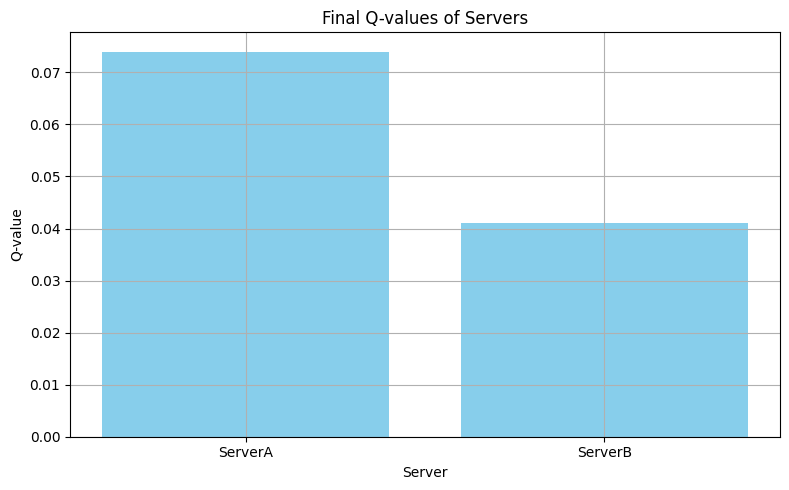

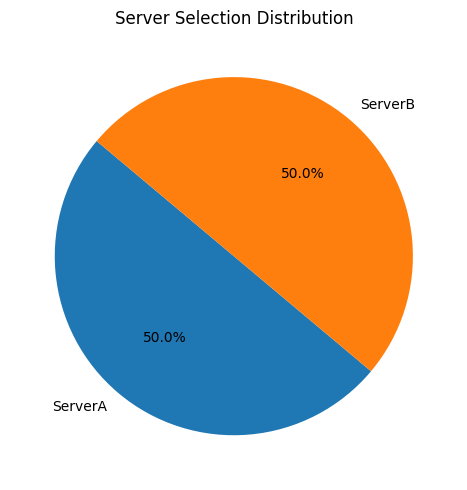

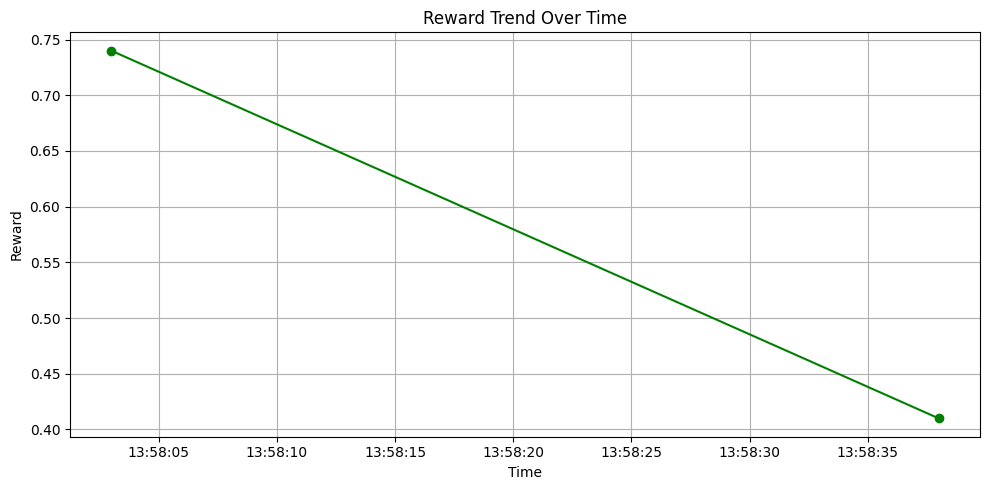

In [ ]:
import matplotlib.pyplot as plt
import sqlite3
import pandas as pd

def plot_q_values(db_path="load_balancer.db"):
    conn = sqlite3.connect(db_path)

    # Read Q-values of all servers
    df = pd.read_sql_query("SELECT name, q_value FROM servers", conn)
    conn.close()

    plt.figure(figsize=(8, 5))
    plt.bar(df['name'], df['q_value'], color='skyblue')
    plt.title("Final Q-values of Servers")
    plt.xlabel("Server")
    plt.ylabel("Q-value")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("q_values.png")
    plt.show()

def plot_server_selections(db_path="load_balancer.db"):
    conn = sqlite3.connect(db_path)

    # Count how many times each server was selected
    df = pd.read_sql_query("""
        SELECT server, COUNT(*) as count FROM request_logs GROUP BY server
    """, conn)
    conn.close()

    plt.figure(figsize=(8, 5))
    plt.pie(df['count'], labels=df['server'], autopct='%1.1f%%', startangle=140)
    plt.title("Server Selection Distribution")
    plt.tight_layout()
    plt.savefig("server_distribution.png")
    plt.show()

def plot_reward_trend(db_path="load_balancer.db"):
    conn = sqlite3.connect(db_path)

    df = pd.read_sql_query("""
        SELECT reward, timestamp FROM request_logs ORDER BY timestamp
    """, conn)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    conn.close()

    plt.figure(figsize=(10, 5))
    plt.plot(df['timestamp'], df['reward'], marker='o', linestyle='-', color='green')
    plt.title("Reward Trend Over Time")
    plt.xlabel("Time")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("reward_trend.png")
    plt.show()

# Call all plots
if __name__ == "__main__":
    plot_q_values()
    plot_server_selections()
    plot_reward_trend()


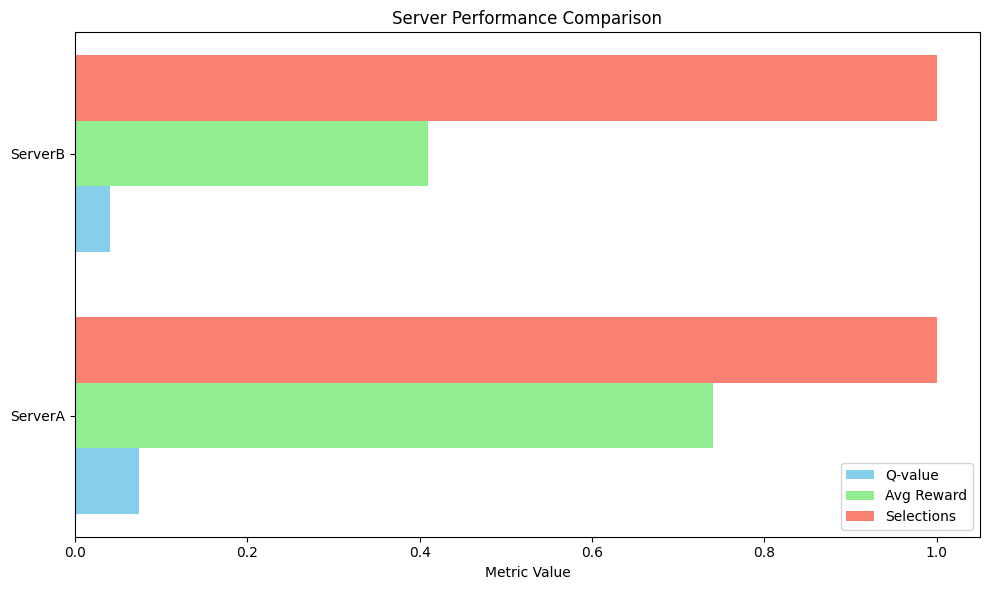

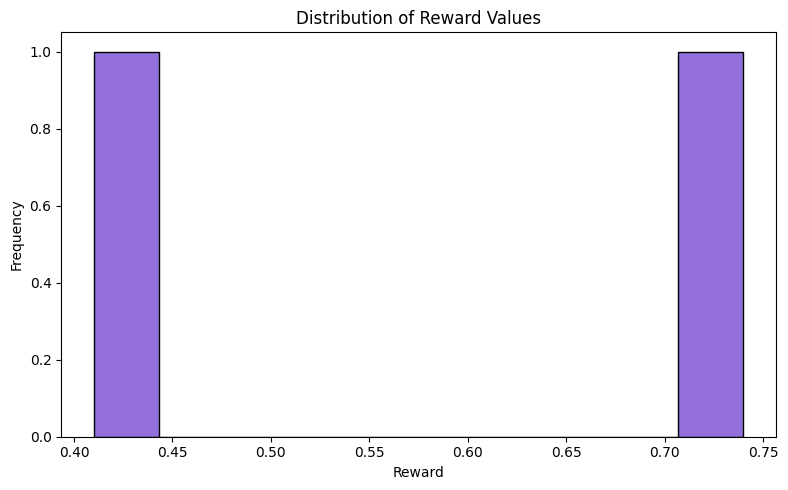

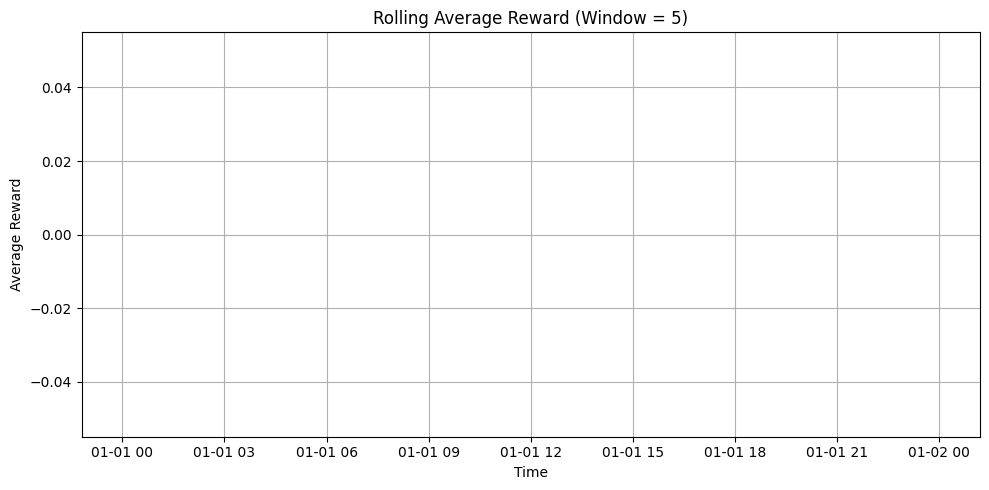

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "load_balancer.db"

# 1. Q-value Evolution Over Time (requires logged q-values per update)
def plot_q_value_evolution(csv_path="q_log.csv"):
    df = pd.read_csv(csv_path)
    plt.figure(figsize=(10, 5))
    for server in df['server'].unique():
        sub_df = df[df['server'] == server]
        plt.plot(sub_df['step'], sub_df['q_value'], marker='o', label=server)

    plt.title("Q-value Evolution Over Time")
    plt.xlabel("Request Step")
    plt.ylabel("Q-value")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("q_value_evolution.png")
    plt.show()

# 2. Active Connections Over Time (simulate/log separately)
def plot_connection_trend(csv_path="connection_log.csv"):
    df = pd.read_csv(csv_path)
    plt.figure(figsize=(10, 5))
    for server in df.columns[1:]:
        plt.plot(df['time'], df[server], label=server)

    plt.title("Server Connections Over Time")
    plt.xlabel("Time")
    plt.ylabel("Connections")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("connection_trend.png")
    plt.show()

# 3. Server Performance Comparison
def plot_server_comparison(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    servers = pd.read_sql_query("SELECT name, q_value, connections FROM servers", conn)
    logs = pd.read_sql_query("SELECT server, reward FROM request_logs", conn)
    conn.close()

    avg_reward = logs.groupby('server')['reward'].mean().reset_index()
    selections = logs['server'].value_counts().reset_index()
    selections.columns = ['server', 'selections']

    merged = servers.merge(avg_reward, left_on='name', right_on='server').merge(
        selections, left_on='name', right_on='server')

    plt.figure(figsize=(10, 6))
    bar_width = 0.25
    index = range(len(merged))

    plt.barh(index, merged['q_value'], bar_width, label='Q-value', color='skyblue')
    plt.barh([i + bar_width for i in index], merged['reward'], bar_width, label='Avg Reward', color='lightgreen')
    plt.barh([i + 2*bar_width for i in index], merged['selections'], bar_width, label='Selections', color='salmon')

    plt.yticks([i + bar_width for i in index], merged['name'])
    plt.xlabel("Metric Value")
    plt.title("Server Performance Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig("server_comparison.png")
    plt.show()

# 4. Reward Histogram
def plot_reward_distribution(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT reward FROM request_logs", conn)
    conn.close()

    plt.figure(figsize=(8, 5))
    plt.hist(df['reward'], bins=10, color='mediumpurple', edgecolor='black')
    plt.title("Distribution of Reward Values")
    plt.xlabel("Reward")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig("reward_distribution.png")
    plt.show()

# 5. Rolling Average Reward Plot
def plot_rolling_avg_reward(db_path=DB_PATH):
    conn = sqlite3.connect(db_path)
    df = pd.read_sql_query("SELECT reward, timestamp FROM request_logs ORDER BY timestamp", conn)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    conn.close()

    df['rolling_avg'] = df['reward'].rolling(window=5).mean()

    plt.figure(figsize=(10, 5))
    plt.plot(df['timestamp'], df['rolling_avg'], color='darkorange', linewidth=2)
    plt.title("Rolling Average Reward (Window = 5)")
    plt.xlabel("Time")
    plt.ylabel("Average Reward")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("rolling_avg_reward.png")
    plt.show()

# Uncomment to run individual graphs
if __name__ == "__main__":
    # plot_q_value_evolution()  # Requires q_log.csv with columns: step, server, q_value
    # plot_connection_trend()  # Requires connection_log.csv
    plot_server_comparison()
    plot_reward_distribution()
    plot_rolling_avg_reward()
